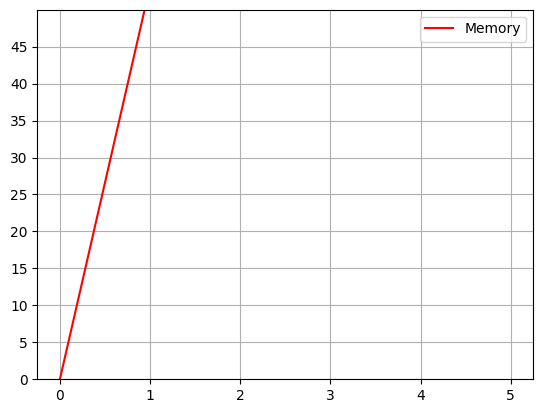

In [1]:
from tkinter import *
from tkinter import ttk
import psutil  # Для получения информации о процессах и ресурсах системы
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk
import numpy as np
import matplotlib.animation as animation
from tkinter import messagebox as mb

class ProcessManagerApp:
    def __init__(self, root):

        self.frame1 = Frame(root)
        self.frame1 = LabelFrame(text="Менеджер процессов")
        self.frame1.pack(fill=BOTH,expand=1)

        self.frame2 = Frame(root)
        self.frame2 = LabelFrame(text="График процессов")

        self.status=1

        self.move_button1=Button(self.frame1,text='Графики',command=self.move_page)
        self.move_button1.grid(row=2,column=40,ipadx=5, ipady=5)

        self.move_button2=Button(self.frame2,text='Менеджер',command=self.move_page)
        self.move_button2.pack()

        # Создаем таблицу для списка процессов
        self.process_tree = ttk.Treeview(self.frame1, columns=("PID", "Имя процесса", "ЦП", "Память"),show="headings")
        self.process_tree.heading("PID", text="PID",command=lambda: self.sortar(0,_))
        self.process_tree.heading("Имя процесса", text="Имя процесса",command=lambda: self.sortar(1,_))
        self.process_tree.heading("ЦП", text="ЦП",command=lambda: self.sortar(2,_))
        self.process_tree.heading("Память", text="Память",command=lambda: self.sortar(3,_))
        self.process_tree.grid(row=1,column=0,columnspan=100)

        # Создаем кнопку для Удаления списка процессов
        self.del_button = Button(self.frame1, text="Удалить", command=self.kill_process)
        self.del_button.grid(row=2,column=99,ipadx=5, ipady=5)

        self.search_text = Label(self.frame1,text="Поиск")
        self.search_text.grid(row=0,column=0)
        
        self.entry_bar = Entry(self.frame1,width=25,validate='key',validatecommand=(self.frame1.register(self.search),"%P"))
        self.entry_bar.grid(row=0,column=1)
        
        self.inter_text = Label(self.frame1,text = "Интервал обновления")
        self.inter_text.grid(row=0,column=75)

        self.entry_int = Entry(self.frame1,width=25,validate='key',validatecommand=(self.frame1.register(self.bar),"%P"))
        self.entry_int.grid(row=0,column=76)

        self.menu=Menu(self.frame1)
        self.menu.add_command(label="File")
        root.config(menu=self.menu) 

        self.var=IntVar()
        self.var.set(0)
        self.button_memory=Radiobutton(self.frame2,text='memory',variable=self.var,value=0,command=self.animate)
        self.button_cpu=Radiobutton(self.frame2,text='cpu',variable=self.var,value=1,command=self.animate)
        self.button_ssd=Radiobutton(self.frame2,text='ssd',variable=self.var,value=2,command=self.animate)
        self.button_net=Radiobutton(self.frame2,text='net',variable=self.var,value=3,command=self.animate)
        self.button_memory.pack()
        self.button_cpu.pack()
        self.button_ssd.pack()
        self.button_net.pack()
        # TODO: Добавьте графическое представление ресурсов системы (ЦП, память, диск, сеть)
        self.fig, self.ax = plt.subplots()
        self.canvas = FigureCanvasTkAgg(self.fig, self.frame2)
        self.canvas.get_tk_widget().pack(anchor=CENTER,fill=BOTH, expand=True)

        self.Time=1
        self.data_memory=[0]
        self.ssd=[0]
        self.cpu=[0]
        self.net_usage=[0]
        self.net_down=[0]
        self.net_upload=[0]
        self.colum=0
        self.enter=""
        self.inter=1
        # Инициализируем список процессов
        #self.update_process_list()
        self.animate()
    def bar(self,text):
        if not text:
            return True
        try:
            int(text)
            self.inter=text
            return True
        except:
            return False
    def search(self,text):
        if text!="":
            self.enter=text.lower()
            self.update_process_list()
        else:
            self.enter=""
        return True
    def sortar(self,col,sel):
        # получаем все значения столбцов в виде отдельного списка
        """ if col == 0:
            self.sortir="PID"
        elif col == 1:
            self.sortir="Name"
        elif col == 2:
            self.sortir="CPU"
        elif col ==3:
            self.sortir="Ram" """
        if col>1:
            rev=True
        else:
            rev=False
        self.colum=col
        pr=[]
        for line in self.process_tree.get_children():
            pr.append(self.process_tree.item(line)['values'])
        pr.sort(key=lambda x: (x[col]),reverse=rev)
        for item in self.process_tree.get_children():
            self.process_tree.delete(item)
        for l in pr:
            self.process_tree.insert("", "end", values=(l[0],l[1],l[2],l[3]))
        if sel:   
            self.process_tree.selection_set(self.process_tree.get_children()[self.index])
        """ l = [(self.process_tree.set(k, col), k) for k in self.process_tree.get_children("")]
        # сортируем список
        l.sort()
        # переупорядочиваем значения в отсортированном порядке
        for index,  (_, k) in enumerate(l):
            self.process_tree.move(k, "", index)
        # в следующий раз выполняем сортировку в обратном порядке
        self.process_tree.heading(col, command=self.sort(col)) """
    def animate(self):
        self.update_process_list()
        self.Time+=1
        self.data_memory.append(self.memory_percent)
        self.cpu.append(self.cpu_percent)
        self.ssd.append(self.memory_info)

        self.netio = psutil.net_io_counters(pernic=True)
        
        self.net_usage.append((self.netio['Ethernet'].bytes_sent + self.netio['Ethernet'].bytes_recv)/8/1024/1024)
        self.net_down.append(self.netio['Ethernet'].bytes_sent/8/1024/1024)
        self.net_upload.append(self.netio['Ethernet'].bytes_recv/8/1024/1024)
        
        t = np.arange(0, self.Time)
        self.ax.clear()
        if self.var.get()==0:
            self.ax.plot(t, self.data_memory,color='red',label='Memory')
            self.ax.set_ylim(0,50)
            self.ax.set_yticks(np.arange(0,50,step=5))
            self.ax.grid(visible=True)
            self.ax.legend()
        elif self.var.get()==1:
            self.ax.plot(t, self.cpu,color='green',label='Cpu')
            self.ax.set_ylim(0,100) 
            self.ax.set_yticks(np.arange(0,100,step=5))
            self.ax.grid(visible=True)
            self.ax.legend()
        elif self.var.get()==2:
            self.ax.plot(t,self.ssd,color='black',label='Ssd') 
            self.ax.set_ylim(0,100)
            self.ax.set_yticks(np.arange(0,100,step=5))
            self.ax.grid(visible=True)
            self.ax.legend()
        else:
            self.ax.plot(t,self.net_usage,label='Net usage')
            self.ax.plot(t,self.net_down,label='Download speed')
            self.ax.plot(t,self.net_upload,label='Upload speed')
            #self.ax.set_yticks(np.arange(0,5,step=5))
            self.ax.grid(visible=True)
            self.ax.legend()
        self.canvas.draw()
        if self.inter:
            self.frame2.after(int(self.inter)*1000, self.animate)
        else:
            self.frame2.after(1000, self.animate)
    def move_page(self):
        if self.status==1:
            self.frame1.pack_forget()
            self.frame2.pack(fill=BOTH,expand=1)
            self.status = 0
        else:
            self.frame2.pack_forget()
            self.frame1.pack(fill=BOTH,expand=1)
            self.status = 1
    def update_process_list(self):
        self.id=[]
        for i in self.process_tree.get_children():
            self.id.append(i)
        selected_item=self.process_tree.selection()
        if selected_item:
            self.index=self.id.index(*selected_item)
        # Очищаем текущий список процессов
        for item in self.process_tree.get_children():
            self.process_tree.delete(item)
        # Получаем список активных процессов
        processes = psutil.process_iter(attrs=['pid', 'name', 'cpu_percent', 'memory_percent','memory_info'])
        if self.enter!="":
            for process in processes:
                pid = process.info['pid']
                name = process.info['name']
                cpu_percent = process.info['cpu_percent']
                self.cpu_percent=psutil.cpu_percent()
                memory_percent = process.info['memory_percent']
                self.memory_percent=psutil.virtual_memory().percent
                self.memory_info=psutil.disk_usage('/')[3]
                if self.enter in name.lower():
                    self.process_tree.insert("", "end", values=(pid, name, cpu_percent, memory_percent))
        else:
            for process in processes:
                pid = process.info['pid']
                name = process.info['name']
                cpu_percent = process.info['cpu_percent']
                self.cpu_percent=psutil.cpu_percent()
                memory_percent = process.info['memory_percent']
                self.memory_percent=psutil.virtual_memory().percent
                self.memory_info=psutil.disk_usage('/')[3]
                self.process_tree.insert("", "end", values=(pid, name, cpu_percent, memory_percent))  
        if selected_item and self.process_tree.get_children():  
            self.process_tree.selection_set(self.process_tree.get_children()[self.index])
            self.sortar(self.colum,selected_item)
        else:
            self.sortar(self.colum,_)
    def kill_process(self):
        self.selected_item = self.process_tree.selection()
        result =  mb.askyesnocancel(title="Подтвержение операции", message="Подтвердить операцию?")
        if result:
            if self.selected_item:
                pid = self.process_tree.item(self.selected_item, 'values')[0]
                try:
                    process = psutil.Process(int(pid))
                    process.terminate()
                    mb.showinfo("Результат", "Операция подтверждена")
                except psutil.NoSuchProcess:
                    mb.showinfo("Результат", "Операция отменена")
                    pass
        else:
            mb.showinfo("Результат", "Операция отменена")

if __name__ == "__main__":
    root = Tk()
    app = ProcessManagerApp(root)
    root.mainloop()
